In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from minisom import MiniSom

In [2]:
#Loading Jan 20 data #### Reproducible for all data files!
jan20 = pd.read_csv('EOSC410 Data/Jan20.csv')
jan20.head()

,N00E,N90E,V,Magnitude,Earthquake_Mag,Focal_Depth (km),Distance_to_epi (km),Station #
0,-0.0017,0.0021,-0.0015,0.003090,5.0,16.1,210.1,0
1,0.0035,-0.0003,0.0039,0.005249,5.0,16.1,210.1,0
2,0.0032,-0.0000,0.0006,0.003256,5.0,16.1,210.1,0
3,-0.0043,0.0011,-0.0043,0.006180,5.0,16.1,210.1,0
4,-0.0015,0.0011,-0.0003,0.001884,5.0,16.1,210.1,0


In [4]:
stations = []
for s in sorted(jan20['Station #'].unique()):
    stations.append(jan20[jan20['Station #'] == s].reset_index(drop=True))

In [5]:
min_len = min(len(st) for st in stations)
stations_trimmed = [st.iloc[-min_len:].copy() for st in stations]

In [6]:
def window_signal(x, window_length=256, overlap=0):
    step = window_length - overlap
    windows = []
    
    for start in range(0, len(x) - window_length + 1, step):
        w = x[start:start + window_length]
        w = (w - np.mean(w)) / (np.std(w) + 1e-8)   # STANDARDIZE WINDOW
        windows.append(w)
        
    return np.array(windows)

In [7]:
window_length = 256
overlap = 0

NS_windows = []
EW_windows = []
V_windows  = []

for st in stations_trimmed:
    NS_windows.append(window_signal(st['N00E'].values, window_length, overlap))
    EW_windows.append(window_signal(st['N90E'].values, window_length, overlap))
    V_windows.append(window_signal(st['V'].values, window_length, overlap))

print(NS_windows[0].shape)
print(EW_windows[0].shape)
print(V_windows[0].shape)

(44, 256)
(44, 256)
(44, 256)


In [8]:
#FFT for each window
def compute_spectrum(windows, dt=0.005):
    fft_vals = np.fft.rfft(windows, axis=1)            # positive freqs
    power = np.abs(fft_vals)**2
    log_power = np.log10(power + 1e-12)                # log power
    freqs = np.fft.rfftfreq(windows.shape[1], dt)
    return log_power, freqs

#FFT to each station

NS_spec = []
EW_spec = []
V_spec  = []

for i in range(len(stations_trimmed)):
    ns_s, freqs = compute_spectrum(NS_windows[i])
    ew_s, _     = compute_spectrum(EW_windows[i])
    v_s, _      = compute_spectrum(V_windows[i])
    
    NS_spec.append(ns_s)
    EW_spec.append(ew_s)
    V_spec.append(v_s)

In [9]:
X = []

meta = []   # to track (station, window)

for st_id in range(len(stations_trimmed)):
    n_ws = NS_spec[st_id].shape[0]
    
    combined = np.concatenate(
        [NS_spec[st_id], EW_spec[st_id], V_spec[st_id]], axis=1
    )
    
    X.append(combined)
    
    for w in range(n_ws):
        meta.append({"station": st_id, "window": w})

X = np.vstack(X)

In [10]:
som_x = 5
som_y = 5
iterations = 5000

som = MiniSom(
    x=som_x, 
    y=som_y, 
    input_len=X.shape[1],
    sigma=1.0,
    learning_rate=0.4,
    neighborhood_function='gaussian',
    random_seed=123
)

som.train_random(X, iterations)

In [11]:

def plot_node_spectra(som, data, freqs, som_x, som_y):
    winners = np.array([som.winner(d) for d in data])
    n_freq = len(freqs)
    
    fig, axes = plt.subplots(som_y, som_x, figsize=(22, 22))
    
    for i in range(som_x):
        for j in range(som_y):
            ax = axes[j, i]
            mask = (winners[:,0] == i) & (winners[:,1] == j)
            
            if mask.any():
                spec_mean = data[mask].mean(axis=0)
                
                NS = spec_mean[0:n_freq]
                EW = spec_mean[n_freq:2*n_freq]
                V  = spec_mean[2*n_freq:3*n_freq]
                
                ax.plot(freqs, NS, label='NS', alpha=0.6)
                ax.plot(freqs, EW, label='EW', alpha=0.6)
                ax.plot(freqs, V,  label='V',  alpha=0.6)
            
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"Node ({i},{j})")
    
    plt.tight_layout()
    plt.show()

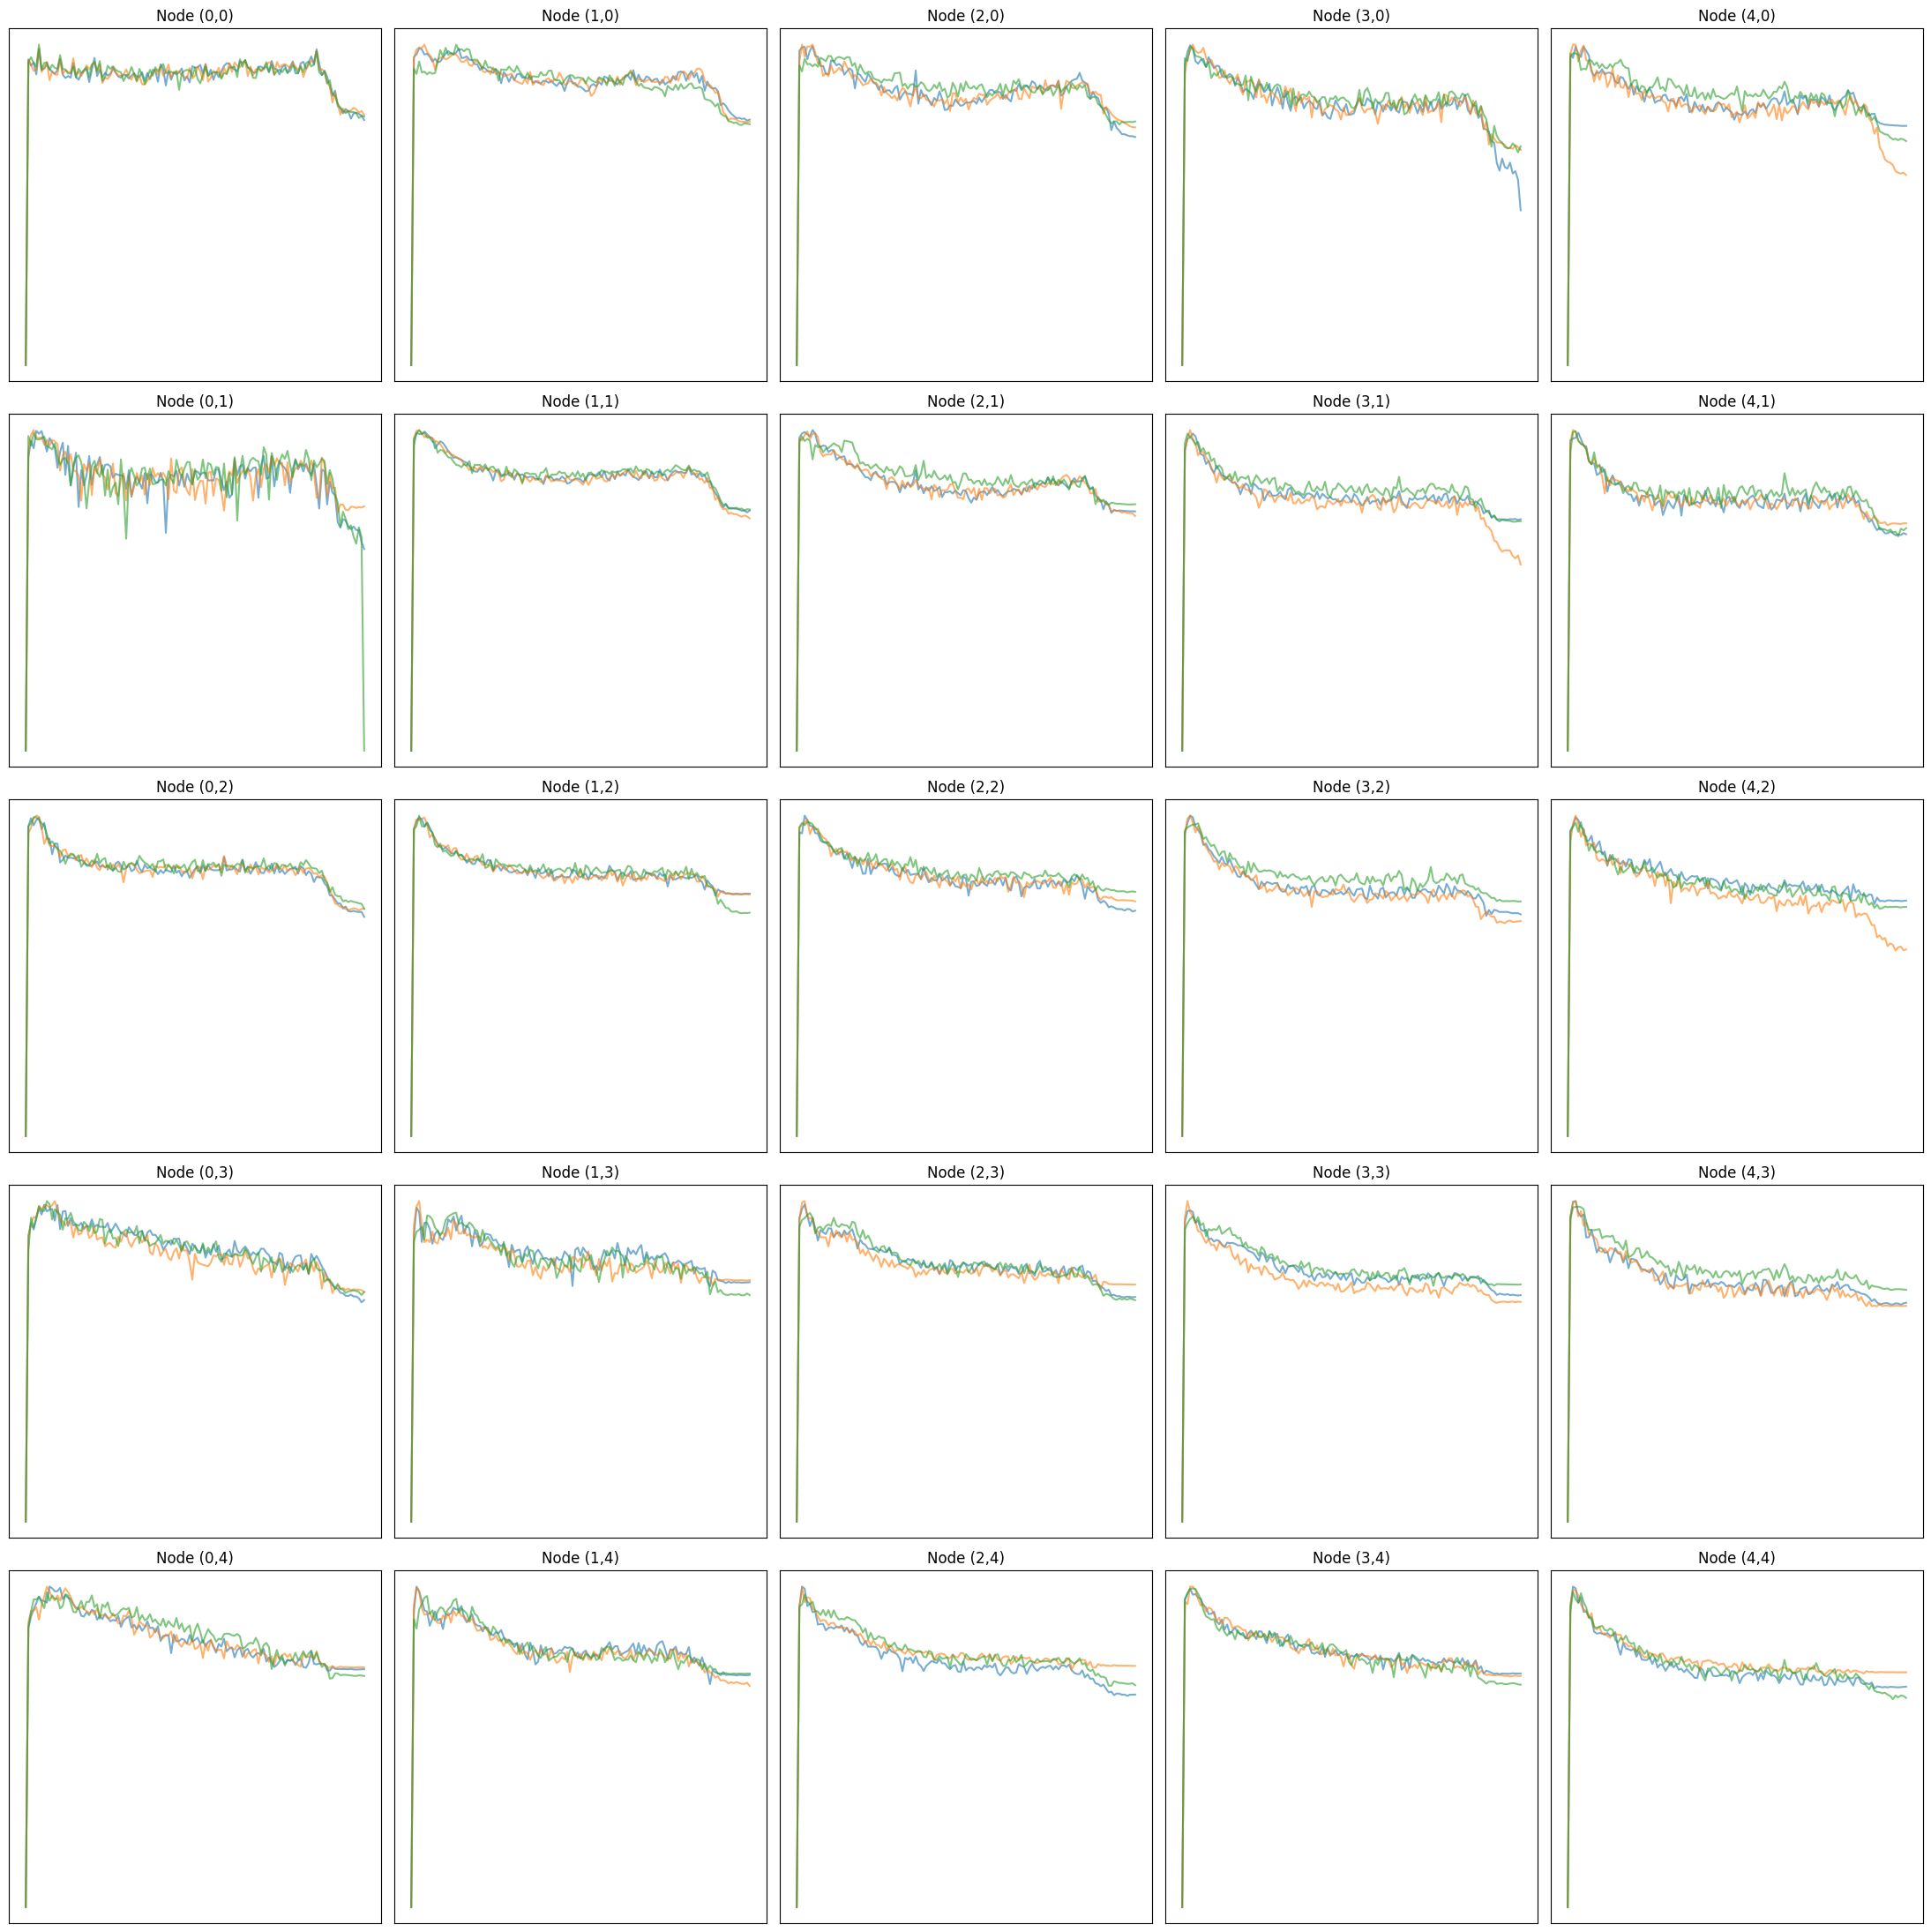

In [12]:
plot_node_spectra(som, X, freqs, som_x, som_y)

In [13]:
import numpy as np

def compute_u_matrix(som):
    umatrix = np.zeros((som._weights.shape[0], som._weights.shape[1]))
    
    for i in range(som._weights.shape[0]):
        for j in range(som._weights.shape[1]):
            neighbors = []
            w = som._weights[i, j]
            
            # Check all 4 neighbors (up, down, left, right)
            if i > 0:
                neighbors.append(som._weights[i-1, j])
            if i < som._weights.shape[0]-1:
                neighbors.append(som._weights[i+1, j])
            if j > 0:
                neighbors.append(som._weights[i, j-1])
            if j < som._weights.shape[1]-1:
                neighbors.append(som._weights[i, j+1])
            
            # Compute average distance to neighbors
            d = np.mean([np.linalg.norm(w - n) for n in neighbors])
            umatrix[i, j] = d
            
    return umatrix

In [14]:
import matplotlib.pyplot as plt

def plot_u_matrix(umatrix):
    plt.figure(figsize=(8, 8))
    plt.imshow(umatrix.T, cmap='viridis', origin='lower')
    plt.colorbar(label='Distance')
    plt.title("SOM U-Matrix")
    plt.xlabel("SOM X")
    plt.ylabel("SOM Y")
    plt.show()


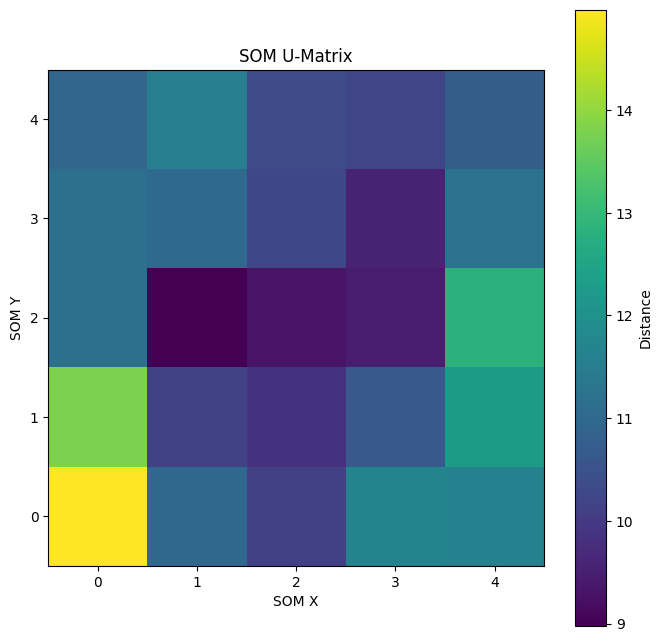

In [15]:
umatrix = compute_u_matrix(som)
plot_u_matrix(umatrix)


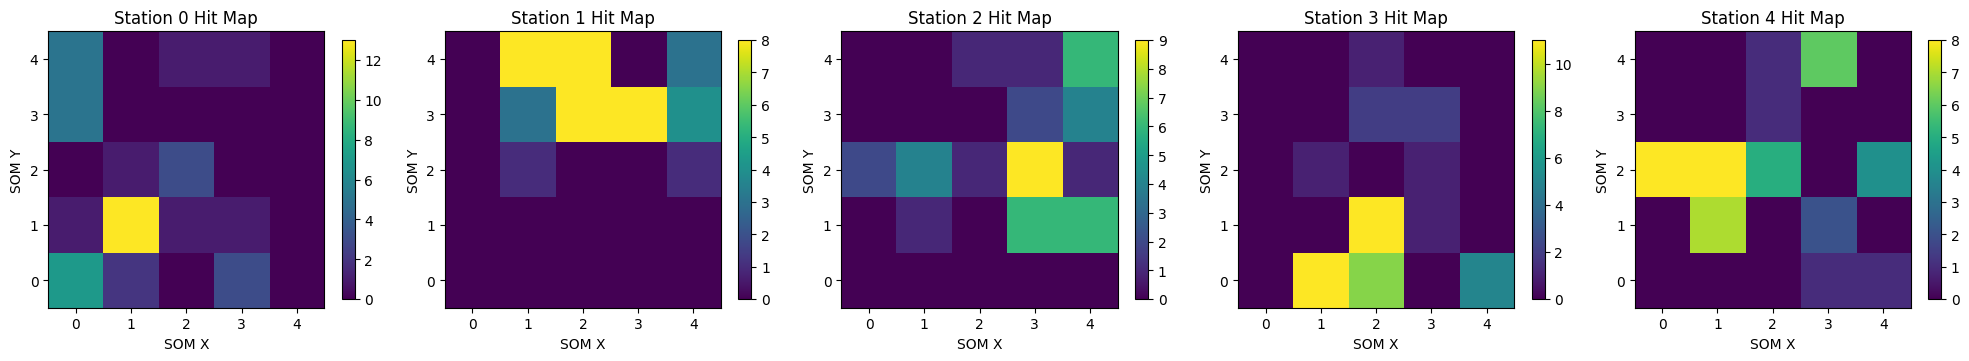

In [16]:
# Get BMU coordinates for every input vector
bmus = np.array([som.winner(x) for x in X])

num_stations = len(stations_trimmed)

# One hit matrix per station
station_hit_maps = [np.zeros((som_x, som_y), dtype=int) for _ in range(num_stations)]

for idx, bmu in enumerate(bmus):
    st = meta[idx]["station"]        # station ID
    x, y = bmu
    station_hit_maps[st][x, y] += 1

import matplotlib.pyplot as plt

def plot_station_hit_maps(station_hit_maps):
    num_stations = len(station_hit_maps)
    fig, axes = plt.subplots(1, num_stations, figsize=(4*num_stations, 4))
    
    for i, ax in enumerate(axes):
        im = ax.imshow(station_hit_maps[i].T, origin='lower', cmap='viridis')
        ax.set_title(f"Station {i} Hit Map")
        ax.set_xlabel("SOM X")
        ax.set_ylabel("SOM Y")
        fig.colorbar(im, ax=ax, shrink=0.7)
    
    plt.tight_layout()
    plt.show()

plot_station_hit_maps(station_hit_maps)